# Knee Osteoarthritis — 5-Grade Training, Merge-at-Inference

**What changed vs the old notebook (and why):**

1. **Trains on the original KL grades 0–4**, then merges probabilities to
   3-class (Healthy / Moderate / Severe) and to binary (Healthy / Diseased)
   *at inference*. Collapsing 0+1 and 3+4 before training throws away the
   ordinal gradient the model needs to learn the fuzzy KL1↔KL2 and KL2↔KL3
   boundaries — which is exactly where the old model failed (Moderate recall ~30%).
2. **No test-set tuning.** Ensemble weights are tuned on the **validation** set
   and applied once to test. The old Fix B searched weights directly on the test
   set, which inflates the reported number without improving the model.
3. **Cross-domain (2020 MedicalExpert-I) is the headline metric** — it is the
   closest thing to "a stranger's X-ray sent to a bot."
4. **Deployment cell** returns a binary screening verdict + a confidence gate +
   a mandatory not-a-diagnosis disclaimer.

**Honest expectations:** 3-class severity realistically tops out ~78–82%.
95% on 3-class severity is above radiologist inter-rater agreement and is not a
real target. The deployable product is **binary screening**, where high-80s to
low-90s is achievable. All three granularities are reported so you can decide.

In [1]:
# ============ PRE-FLIGHT (run first, on a fresh kernel) ============
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
print("Environment configured. NOW import TensorFlow.")

Environment configured. NOW import TensorFlow.


In [2]:
import shutil
import stat            # <-- needed by remove_readonly (was missing in old notebook)
import time
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, DenseNet121, ResNet50V2
from tensorflow.keras.layers import (Dense, GlobalAveragePooling2D, Dropout,
                                     BatchNormalization, Input, Lambda)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import mixed_precision
import tensorflow.keras.backend as K

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)

print(f"TensorFlow : {tf.__version__}    (expect 2.10.x)")
print(f"NumPy      : {np.__version__}")
print(f"OpenCV     : {cv2.__version__}")
print(f"Built with CUDA  : {tf.test.is_built_with_cuda()}")

# ============ GPU CONFIGURATION ============
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs detected: {len(gpus)}")
USE_MIXED_PRECISION = False
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("  Memory growth: ENABLED")
        details = tf.config.experimental.get_device_details(gpus[0])
        cc = details.get('compute_capability', (0, 0))
        print(f"  Device           : {details.get('device_name', 'Unknown')}")
        print(f"  Compute capability: {cc[0]}.{cc[1]}")
        if cc[0] >= 7:
            mixed_precision.set_global_policy('mixed_float16')
            USE_MIXED_PRECISION = True
            print("  Mixed precision  : ENABLED (mixed_float16)")
        else:
            print("  Mixed precision  : SKIPPED (no Tensor Cores)")
    except RuntimeError as e:
        print(" GPU config error:", e)
else:
    print("  No GPU detected.")

tf.config.threading.set_intra_op_parallelism_threads(4)
tf.config.threading.set_inter_op_parallelism_threads(2)
print("Setup OK")

TensorFlow : 2.10.0    (expect 2.10.x)
NumPy      : 1.23.5
OpenCV     : 4.8.1
Built with CUDA  : True
GPUs detected: 1
  Memory growth: ENABLED
  Device           : NVIDIA GeForce RTX 3050 6GB Laptop GPU
  Compute capability: 8.6
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU, compute capability 8.6
  Mixed precision  : ENABLED (mixed_float16)
Setup OK


## Paths & hyperparameters

Note `NUM_CLASSES = 5` now — we train on the raw KL grades. The 3-class and
binary views are derived after prediction.

In [3]:
ORIGINAL_2018  = r"kaggle_dataset_2018"
EXPERT_I_2020  = r"kaggle_dataset2_2020\MedicalExpert-I"
EXPERT_II_2020 = r"kaggle_dataset2_2020\MedicalExpert-II"

# 5-grade datasets we will build
GRADED_DIR     = r"graded_dataset_5"          # train/val/test with folders 0..4
GRADED_EXTRA   = r"graded_extra_test_2020_E1"  # cross-domain test (MedicalExpert-I)

IMG_SIZE    = 320
BATCH_SIZE  = 32          # drop to 16 / 8 if you hit OOM
NUM_CLASSES = 5           # <-- raw KL grades 0..4

GRADE_NAMES   = ['0', '1', '2', '3', '4']
TERNARY_NAMES = ['Healthy', 'Moderate', 'Severe']
BINARY_NAMES  = ['Healthy', 'Diseased']

# How a raw KL grade (0..4) maps to the coarser views
GRADE_TO_TERNARY = {0: 0, 1: 0, 2: 1, 3: 2, 4: 2}   # Healthy / Moderate / Severe
GRADE_TO_BINARY  = {0: 0, 1: 0, 2: 1, 3: 1, 4: 1}   # Healthy / Diseased

for p in [ORIGINAL_2018, EXPERT_I_2020, EXPERT_II_2020]:
    assert os.path.isdir(p), f"NOT FOUND: {p}"
    print(f"OK  {p}")
print(f"BATCH_SIZE = {BATCH_SIZE} (reduce to 16/8 if you see OOM)")

OK  kaggle_dataset_2018
OK  kaggle_dataset2_2020\MedicalExpert-I
OK  kaggle_dataset2_2020\MedicalExpert-II
BATCH_SIZE = 32 (reduce to 16/8 if you see OOM)


## Build the 5-grade dataset (no merging)

2018 train/val/test copied grade-for-grade. 2020 MedicalExpert-II added to the
**training** set only (same as before). MedicalExpert-I is held out entirely as
the cross-domain test set.

In [4]:
def remove_readonly(func, path, excinfo):
    """Fix Windows PermissionError on cleanup."""
    try:
        os.chmod(path, stat.S_IWRITE); func(path)
    except PermissionError:
        time.sleep(0.1)
        try:
            os.chmod(path, stat.S_IWRITE); func(path)
        except Exception:
            print(f"Warning: could not delete locked path: {path}. Restart the kernel.")

# 2020 folder names -> raw grade folder names
MAP_2020_TO_GRADE = {'0Normal': '0', '1Doubtful': '1', '2Mild': '2',
                     '3Moderate': '3', '4Severe': '4'}

if os.path.exists(GRADED_DIR):
    print(f"Cleaning {GRADED_DIR} ...")
    shutil.rmtree(GRADED_DIR, onerror=remove_readonly)

print("Building 5-grade dataset from 2018 (preserving splits)...")
for split in ['train', 'val', 'test']:
    src_split = os.path.join(ORIGINAL_2018, split)
    if not os.path.exists(src_split):
        continue
    for grade in os.listdir(src_split):
        if grade not in GRADE_NAMES:
            continue
        src_dir = os.path.join(src_split, grade)
        if not os.path.isdir(src_dir):
            continue
        dst_dir = os.path.join(GRADED_DIR, split, grade)
        os.makedirs(dst_dir, exist_ok=True)
        for f in os.listdir(src_dir):
            shutil.copy2(os.path.join(src_dir, f),
                         os.path.join(dst_dir, f"2018_g{grade}_{f}"))

print("Adding 2020 MedicalExpert-II into TRAIN...")
if os.path.exists(EXPERT_II_2020):
    for src_folder, grade in MAP_2020_TO_GRADE.items():
        src_dir = os.path.join(EXPERT_II_2020, src_folder)
        if not os.path.exists(src_dir):
            continue
        dst_dir = os.path.join(GRADED_DIR, 'train', grade)
        os.makedirs(dst_dir, exist_ok=True)
        for f in os.listdir(src_dir):
            shutil.copy2(os.path.join(src_dir, f),
                         os.path.join(dst_dir, f"2020E2_{src_folder}_{f}"))
else:
    print(f"Warning: not found {EXPERT_II_2020}")

print("Final 5-grade counts:")
for split in ['train', 'val', 'test']:
    split_dir = os.path.join(GRADED_DIR, split)
    print(f"{split}:")
    if not os.path.exists(split_dir):
        print("  (empty)"); continue
    for cls in sorted(os.listdir(split_dir)):
        cls_dir = os.path.join(split_dir, cls)
        if os.path.isdir(cls_dir):
            print(f"  grade {cls}: {len(os.listdir(cls_dir))}")

Cleaning graded_dataset_5 ...
Building 5-grade dataset from 2018 (preserving splits)...
Adding 2020 MedicalExpert-II into TRAIN...
Final 5-grade counts:
train:
  grade 0: 2789
  grade 1: 1534
  grade 2: 1748
  grade 3: 978
  grade 4: 379
val:
  grade 0: 328
  grade 1: 153
  grade 2: 212
  grade 3: 106
  grade 4: 27
test:
  grade 0: 639
  grade 1: 296
  grade 2: 447
  grade 3: 223
  grade 4: 51


In [5]:
# Cross-domain test set = 2020 MedicalExpert-I, kept at 5 grades
if os.path.exists(GRADED_EXTRA):
    print(f"Cleaning {GRADED_EXTRA} ...")
    shutil.rmtree(GRADED_EXTRA, onerror=remove_readonly)

print("Building cross-domain test from MedicalExpert-I (2020)...")
if os.path.exists(EXPERT_I_2020):
    for src_folder, grade in MAP_2020_TO_GRADE.items():
        src_dir = os.path.join(EXPERT_I_2020, src_folder)
        if not os.path.exists(src_dir):
            continue
        dst_dir = os.path.join(GRADED_EXTRA, grade)
        os.makedirs(dst_dir, exist_ok=True)
        for f in os.listdir(src_dir):
            shutil.copy2(os.path.join(src_dir, f),
                         os.path.join(dst_dir, f"e1_{src_folder}_{f}"))
else:
    print(f"Error: not found {EXPERT_I_2020}")

print("Cross-domain 5-grade counts:")
if os.path.exists(GRADED_EXTRA):
    for cls in sorted(os.listdir(GRADED_EXTRA)):
        cls_dir = os.path.join(GRADED_EXTRA, cls)
        if os.path.isdir(cls_dir):
            print(f"  grade {cls}: {len(os.listdir(cls_dir))}")

Cleaning graded_extra_test_2020_E1 ...
Building cross-domain test from MedicalExpert-I (2020)...
Cross-domain 5-grade counts:
  grade 0: 514
  grade 1: 477
  grade 2: 232
  grade 3: 221
  grade 4: 206


## CLAHE preprocessing + generators + tf.data prefetch
(Identical to your proven pipeline, just with 5 classes.)

In [6]:
def clahe_preprocess(img):
    """CLAHE contrast enhancement (your Fix 2)."""
    img = img.astype(np.uint8)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    return cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB).astype('float32')

train_datagen = ImageDataGenerator(
    preprocessing_function=clahe_preprocess,
    rotation_range=20, width_shift_range=0.15, height_shift_range=0.15,
    horizontal_flip=True, zoom_range=0.15, brightness_range=[0.8, 1.2],
    shear_range=10, fill_mode='reflect',
)
eval_datagen = ImageDataGenerator(preprocessing_function=clahe_preprocess)

train_gen = train_datagen.flow_from_directory(
    os.path.join(GRADED_DIR, 'train'), target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True)
val_gen = eval_datagen.flow_from_directory(
    os.path.join(GRADED_DIR, 'val'), target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
test_gen = eval_datagen.flow_from_directory(
    os.path.join(GRADED_DIR, 'test'), target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
extra_gen = eval_datagen.flow_from_directory(
    GRADED_EXTRA, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

print("Class indices (should be {'0':0,...,'4':4}):", train_gen.class_indices)
assert train_gen.class_indices == {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}, \
    "Grade folders not in expected order — check folder names."

AUTOTUNE = tf.data.AUTOTUNE
def to_tf_dataset(keras_gen, training=False, n_classes=NUM_CLASSES):
    output_sig = (
        tf.TensorSpec(shape=(None, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, n_classes), dtype=tf.float32),
    )
    ds = tf.data.Dataset.from_generator(lambda: keras_gen, output_signature=output_sig)
    if training:
        ds = ds.repeat()
    return ds.prefetch(AUTOTUNE)

val_ds   = to_tf_dataset(val_gen,   training=False)
STEPS_TRAIN = len(train_gen)
STEPS_VAL   = len(val_gen)
STEPS_TEST  = len(test_gen)
STEPS_EXTRA = len(extra_gen)
print(f"Steps — train: {STEPS_TRAIN}, val: {STEPS_VAL}, test: {STEPS_TEST}, extra: {STEPS_EXTRA}")

Found 7428 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
Class indices (should be {'0':0,...,'4':4}): {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}
Steps — train: 233, val: 26, test: 52, extra: 52


## Mixup + class weights + Weighted Focal Loss
(Your Fix 4 + your loss, unchanged.)

In [7]:
class MixupGenerator(tf.keras.utils.Sequence):
    def __init__(self, base_gen, alpha=0.2):
        self.base_gen = base_gen; self.alpha = alpha
    def __len__(self):
        return len(self.base_gen)
    def __getitem__(self, idx):
        X1, y1 = self.base_gen[idx]
        X2, y2 = self.base_gen[(idx + 1) % len(self.base_gen)]
        n = min(len(X1), len(X2))
        X1, y1, X2, y2 = X1[:n], y1[:n], X2[:n], y2[:n]
        lam = np.random.beta(self.alpha, self.alpha)
        return (lam * X1 + (1 - lam) * X2, lam * y1 + (1 - lam) * y2)
    def on_epoch_end(self):
        self.base_gen.on_epoch_end()

train_gen_mixup = MixupGenerator(train_gen, alpha=0.2)
train_ds = to_tf_dataset(train_gen_mixup, training=True)
print("Mixup + tf.data pipeline ready")

class_weights_arr = compute_class_weight(
    class_weight='balanced', classes=np.unique(train_gen.classes), y=train_gen.classes)
CLASS_WEIGHTS_LIST = [float(w) for w in class_weights_arr]
print("5-grade class weights:", CLASS_WEIGHTS_LIST)

class WeightedFocalLoss(tf.keras.losses.Loss):
    """Focal loss with class weights baked in. Mixed-precision safe."""
    def __init__(self, gamma=2.0, alpha=0.25, class_weights=None,
                 name="weighted_focal_loss"):
        super().__init__(name=name)
        self.gamma = float(gamma); self.alpha = float(alpha)
        self.class_weights_list = (
            [float(w) for w in class_weights] if class_weights is not None else None)
        self._weights_tensor = (
            tf.constant(self.class_weights_list, dtype=tf.float32)
            if self.class_weights_list is not None else None)
    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32); y_pred = tf.cast(y_pred, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = self.alpha * tf.pow(1.0 - y_pred, self.gamma)
        loss = focal_weight * cross_entropy
        if self._weights_tensor is not None:
            sample_w = tf.reduce_sum(y_true * self._weights_tensor, axis=-1, keepdims=True)
            loss = loss * sample_w
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))
    def get_config(self):
        return {"gamma": self.gamma, "alpha": self.alpha,
                "class_weights": self.class_weights_list, "name": self.name}

Mixup + tf.data pipeline ready
5-grade class weights: [0.532664037289351, 0.9684485006518905, 0.8498855835240274, 1.5190184049079754, 3.9197889182058048]


## Model builder + training routine
Same two-phase transfer-learning recipe you used. Output layer is now 5-way.

In [8]:
def get_preprocess_fn(model_name):
    if model_name == 'efficientnet':
        from tensorflow.keras.applications.efficientnet import preprocess_input
    elif model_name == 'densenet':
        from tensorflow.keras.applications.densenet import preprocess_input
    elif model_name == 'resnet':
        from tensorflow.keras.applications.resnet_v2 import preprocess_input
    return preprocess_input

def build_model(model_name='efficientnet'):
    preprocess_fn = get_preprocess_fn(model_name)
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = Lambda(preprocess_fn)(inputs)
    if model_name == 'efficientnet':
        base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=x)
    elif model_name == 'densenet':
        base = DenseNet121(weights='imagenet', include_top=False, input_tensor=x)
    elif model_name == 'resnet':
        base = ResNet50V2(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False
    h = base.output
    h = GlobalAveragePooling2D()(h)
    h = BatchNormalization()(h)
    h = Dense(256, activation='relu')(h); h = Dropout(0.5)(h)
    h = Dense(128, activation='relu')(h); h = Dropout(0.3)(h)
    out = Dense(NUM_CLASSES, activation='softmax', dtype='float32')(h)
    return Model(inputs, out), base

def make_callbacks(weights_save_path, patience):
    return [
        EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-8, verbose=1),
        ModelCheckpoint(weights_save_path, monitor='val_accuracy',
                        save_best_only=True, save_weights_only=True, verbose=1),
    ]

def train_full(model_name, save_path, epochs_phase1=15, epochs_phase2=20,
               unfreeze_last=60, gamma=2.0, class_weights=None):
    if class_weights is None:
        class_weights = CLASS_WEIGHTS_LIST
    print(f"{'='*25} Training {model_name.upper()} {'='*25}")
    model, base = build_model(model_name)
    if not save_path.endswith('.h5'):
        save_path = save_path.rsplit('.', 1)[0] + '.h5'

    # Phase 1: head only
    model.compile(optimizer=Adam(1e-3),
                  loss=WeightedFocalLoss(gamma=gamma, class_weights=class_weights),
                  metrics=['accuracy'])
    h1 = model.fit(train_ds, steps_per_epoch=STEPS_TRAIN,
                   validation_data=val_ds, validation_steps=STEPS_VAL,
                   epochs=epochs_phase1, callbacks=make_callbacks(save_path, 6), verbose=1)

    # Phase 2: fine-tune top layers
    base.trainable = True
    for layer in base.layers[:-unfreeze_last]:
        layer.trainable = False
    model.compile(optimizer=Adam(1e-5),
                  loss=WeightedFocalLoss(gamma=gamma, class_weights=class_weights),
                  metrics=['accuracy'])
    h2 = model.fit(train_ds, steps_per_epoch=STEPS_TRAIN,
                   validation_data=val_ds, validation_steps=STEPS_VAL,
                   epochs=epochs_phase2, callbacks=make_callbacks(save_path, 8), verbose=1)

    final_path = save_path.replace('.h5', '_final.h5')
    model.save_weights(final_path)
    print(f"Best checkpoint -> {save_path}\nFinal weights   -> {final_path}")
    return model, h1, h2

In [ ]:
# ===== WARM START — run on a fresh kernel INSTEAD of the 4 training cells =====
# Rebuilds the 5-grade ensemble + Stage-2 specialists from saved weights. No training.
def build_specialist(model_name='efficientnet'):
    preprocess_fn = get_preprocess_fn(model_name)
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = Lambda(preprocess_fn)(inputs)
    if model_name == 'efficientnet':
        base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=x)
    elif model_name == 'densenet':
        base = DenseNet121(weights='imagenet', include_top=False, input_tensor=x)
    elif model_name == 'resnet':
        base = ResNet50V2(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False
    h = base.output
    h = GlobalAveragePooling2D()(h)
    h = BatchNormalization()(h)
    h = Dense(256, activation='relu')(h); h = Dropout(0.5)(h)
    h = Dense(128, activation='relu')(h); h = Dropout(0.3)(h)
    out = Dense(2, activation='softmax', dtype='float32')(h)
    return Model(inputs, out), base

def _rebuild(builder, name, path):
    m, b = builder(name); b.trainable = True
    for l in b.layers[:-60]: l.trainable = False
    m.load_weights(path); return m

model_eff    = _rebuild(build_model, 'efficientnet', 'final_g5_efficientnet.h5')
model_dense  = _rebuild(build_model, 'densenet',     'final_g5_densenet.h5')
model_resnet = _rebuild(build_model, 'resnet',       'final_g5_resnet.h5')
spec_eff     = _rebuild(build_specialist, 'efficientnet', 'spec_efficientnet_final.h5')
spec_dense   = _rebuild(build_specialist, 'densenet',     'spec_densenet_final.h5')
spec_resnet  = _rebuild(build_specialist, 'resnet',       'spec_resnet_final.h5')

import json
with open('g5_model_config.json') as f: cfg = json.load(f)
ENS_W = tuple(cfg['ensemble_weights'])
CASCADE_S1_THR, CASCADE_S2_THR = 0.38, 0.50
print("Warm start complete. ENS_W =", ENS_W, "| thresholds:", CASCADE_S1_THR, CASCADE_S2_THR)

## Train the three backbones on 5 grades
Each is ~30–60 min on your GPU. Reduce epochs if you just want a quick pass.

In [9]:
model_eff, _, _ = train_full('efficientnet', 'g5_efficientnet.h5',
                             epochs_phase1=15, epochs_phase2=20)

========================= Training EFFICIENTNET =========================
Epoch 1/15
233/233 [==============================] - ETA: 0s - loss: 0.2857 - accuracy: 0.3288
Epoch 1: val_accuracy improved from -inf to 0.27724, saving model to g5_efficientnet.h5
233/233 [==============================] - 313s 1s/step - loss: 0.2857 - accuracy: 0.3288 - val_loss: 0.2061 - val_accuracy: 0.2772 - lr: 0.0010
Epoch 2/15
233/233 [==============================] - ETA: 0s - loss: 0.2211 - accuracy: 0.3488
Epoch 2: val_accuracy improved from 0.27724 to 0.38741, saving model to g5_efficientnet.h5
233/233 [==============================] - 242s 1s/step - loss: 0.2211 - accuracy: 0.3488 - val_loss: 0.1896 - val_accuracy: 0.3874 - lr: 0.0010
Epoch 3/15
233/233 [==============================] - ETA: 0s - loss: 0.2073 - accuracy: 0.3842
Epoch 3: val_accuracy did not improve from 0.38741
233/233 [==============================] - 237s 1s/step - loss: 0.2073 - accuracy: 0.3842 - val_loss: 0.1935 - val_acc

In [10]:
model_dense, _, _ = train_full('densenet', 'g5_densenet.h5',
                               epochs_phase1=15, epochs_phase2=20)

========================= Training DENSENET =========================
Epoch 1/15
233/233 [==============================] - ETA: 0s - loss: 0.2662 - accuracy: 0.3047
Epoch 1: val_accuracy improved from -inf to 0.32688, saving model to g5_densenet.h5
233/233 [==============================] - 248s 1s/step - loss: 0.2662 - accuracy: 0.3047 - val_loss: 0.1995 - val_accuracy: 0.3269 - lr: 0.0010
Epoch 2/15
233/233 [==============================] - ETA: 0s - loss: 0.2198 - accuracy: 0.3630
Epoch 2: val_accuracy improved from 0.32688 to 0.42010, saving model to g5_densenet.h5
233/233 [==============================] - 248s 1s/step - loss: 0.2198 - accuracy: 0.3630 - val_loss: 0.1988 - val_accuracy: 0.4201 - lr: 0.0010
Epoch 3/15
233/233 [==============================] - ETA: 0s - loss: 0.2037 - accuracy: 0.4016
Epoch 3: val_accuracy did not improve from 0.42010
233/233 [==============================] - 251s 1s/step - loss: 0.2037 - accuracy: 0.4016 - val_loss: 0.1882 - val_accuracy: 0.412

In [11]:
model_resnet, _, _ = train_full('resnet', 'g5_resnet.h5',
                                epochs_phase1=15, epochs_phase2=20)
print("All three 5-grade models trained.")

========================= Training RESNET =========================
Epoch 1/15
233/233 [==============================] - ETA: 0s - loss: 0.2974 - accuracy: 0.3130
Epoch 1: val_accuracy improved from -inf to 0.42978, saving model to g5_resnet.h5
233/233 [==============================] - 253s 1s/step - loss: 0.2974 - accuracy: 0.3130 - val_loss: 0.1984 - val_accuracy: 0.4298 - lr: 0.0010
Epoch 2/15
233/233 [==============================] - ETA: 0s - loss: 0.2223 - accuracy: 0.3555
Epoch 2: val_accuracy improved from 0.42978 to 0.43341, saving model to g5_resnet.h5
233/233 [==============================] - 242s 1s/step - loss: 0.2223 - accuracy: 0.3555 - val_loss: 0.1862 - val_accuracy: 0.4334 - lr: 0.0010
Epoch 3/15
233/233 [==============================] - ETA: 0s - loss: 0.2098 - accuracy: 0.3727
Epoch 3: val_accuracy did not improve from 0.43341
233/233 [==============================] - 255s 1s/step - loss: 0.2098 - accuracy: 0.3727 - val_loss: 0.1780 - val_accuracy: 0.4322 - lr

## Test-Time Augmentation (your function, unchanged)

In [12]:
def predict_with_tta(model, source_dir, n_aug=5):
    base_gen = eval_datagen.flow_from_directory(
        source_dir, target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
    n = base_gen.samples
    probs = np.zeros((n, NUM_CLASSES))
    base_gen.reset()
    probs += model.predict(base_gen, verbose=0)
    tta_aug = ImageDataGenerator(
        preprocessing_function=clahe_preprocess, rotation_range=10,
        horizontal_flip=True, zoom_range=0.05,
        width_shift_range=0.05, height_shift_range=0.05)
    for i in range(n_aug):
        gen_aug = tta_aug.flow_from_directory(
            source_dir, target_size=(IMG_SIZE, IMG_SIZE),
            batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False, seed=42 + i)
        probs += model.predict(gen_aug, verbose=0)
    probs /= (n_aug + 1)
    return probs, base_gen.classes
print("TTA function defined.")

TTA function defined.


## Merge helpers — turn 5-grade probabilities into 3-class and binary

`P(Healthy)=P0+P1`, `P(Moderate)=P2`, `P(Severe)=P3+P4`.
Binary `P(Diseased)=P2+P3+P4`.

In [13]:
def probs5_to_ternary(p5):
    healthy  = p5[:, 0] + p5[:, 1]
    moderate = p5[:, 2]
    severe   = p5[:, 3] + p5[:, 4]
    return np.stack([healthy, moderate, severe], axis=1)

def probs5_to_binary(p5):
    healthy  = p5[:, 0] + p5[:, 1]
    diseased = p5[:, 2] + p5[:, 3] + p5[:, 4]
    return np.stack([healthy, diseased], axis=1)

def y5_to_ternary(y5):
    return np.array([GRADE_TO_TERNARY[int(y)] for y in y5])

def y5_to_binary(y5):
    return np.array([GRADE_TO_BINARY[int(y)] for y in y5])

def report_all_views(p5, y5, title=""):
    """Print 5-grade, 3-class and binary accuracy + reports from one prob array."""
    print("=" * 68); print(title); print("=" * 68)
    # 5-grade
    y5_hat = np.argmax(p5, axis=1)
    print(f"[5-grade]  acc = {accuracy_score(y5, y5_hat)*100:.2f}%")
    # 3-class
    t_true = y5_to_ternary(y5); t_hat = np.argmax(probs5_to_ternary(p5), axis=1)
    print(f"[3-class]  acc = {accuracy_score(t_true, t_hat)*100:.2f}%  "
          f"macro-F1 = {f1_score(t_true, t_hat, average='macro'):.4f}")
    print(classification_report(t_true, t_hat, target_names=TERNARY_NAMES, digits=4))
    # binary
    b_true = y5_to_binary(y5); b_hat = np.argmax(probs5_to_binary(p5), axis=1)
    print(f"[binary ]  acc = {accuracy_score(b_true, b_hat)*100:.2f}%  "
          f"macro-F1 = {f1_score(b_true, b_hat, average='macro'):.4f}")
    print(classification_report(b_true, b_hat, target_names=BINARY_NAMES, digits=4))
    return t_true, t_hat, b_true, b_hat

def plot_cm(y_true, y_pred, names, title, cmap='Greens'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=names, yticklabels=names, annot_kws={'size': 13})
    plt.title(title); plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()

## Per-model TTA on the test set + uniform ensemble

TTA on test set (3 models)...
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
EfficientNet  5-grade test acc: 49.03%
DenseNet      5-grade test acc: 46.98%
ResNet        5-grade test acc: 58.27%
UNIFORM ENSEMBLE (test set)
[5-grade]  acc = 53.26%
[3-class]  acc = 67.93%  macro-F1 = 0.5086
  

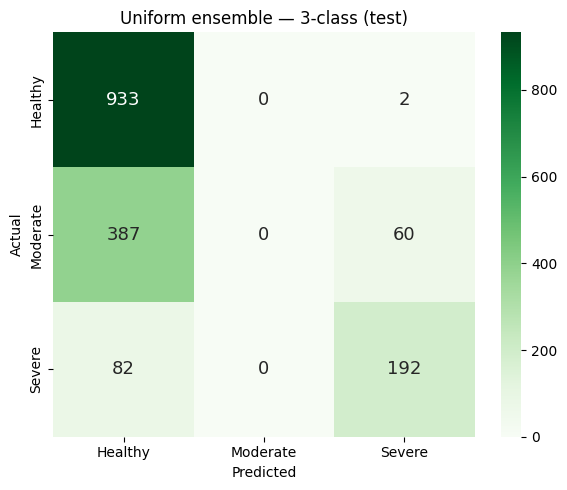

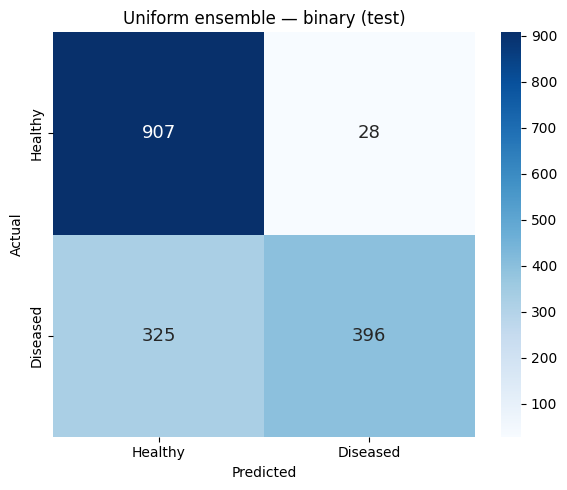

In [14]:
test_dir = os.path.join(GRADED_DIR, 'test')
print("TTA on test set (3 models)...")
eff_p,    y_test = predict_with_tta(model_eff,    test_dir, n_aug=5)
dense_p,  _      = predict_with_tta(model_dense,  test_dir, n_aug=5)
resnet_p, _      = predict_with_tta(model_resnet, test_dir, n_aug=5)

for name, p in [('EfficientNet', eff_p), ('DenseNet', dense_p), ('ResNet', resnet_p)]:
    y5h = np.argmax(p, axis=1)
    print(f"{name:13s} 5-grade test acc: {accuracy_score(y_test, y5h)*100:.2f}%")

uniform_p = (eff_p + dense_p + resnet_p) / 3.0
report_all_views(uniform_p, y_test, "UNIFORM ENSEMBLE (test set)")
t_true, t_hat, b_true, b_hat = (y5_to_ternary(y_test),
                                np.argmax(probs5_to_ternary(uniform_p), axis=1),
                                y5_to_binary(y_test),
                                np.argmax(probs5_to_binary(uniform_p), axis=1))
plot_cm(t_true, t_hat, TERNARY_NAMES, "Uniform ensemble — 3-class (test)", 'Greens')
plot_cm(b_true, b_hat, BINARY_NAMES,  "Uniform ensemble — binary (test)", 'Blues')

## Tune ensemble weights on VALIDATION (no test leakage), apply to test

We optimise the 5-grade-merged **3-class macro-F1** on the validation set, then
report the chosen weights once on the test set.

TTA on validation set (3 models)...
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Best val weights (by 3-class macro-F1): (0.0, 0.0, 1.0)  val_macroF1=0.5625
WEIGHTED ENSEMBLE (0.0, 0.0, 1.0) (test set)
[5-grade]  acc = 58.27%
[3-class]  acc = 70.53%  macro-F1 = 0.5554
              precision    recall  f1-

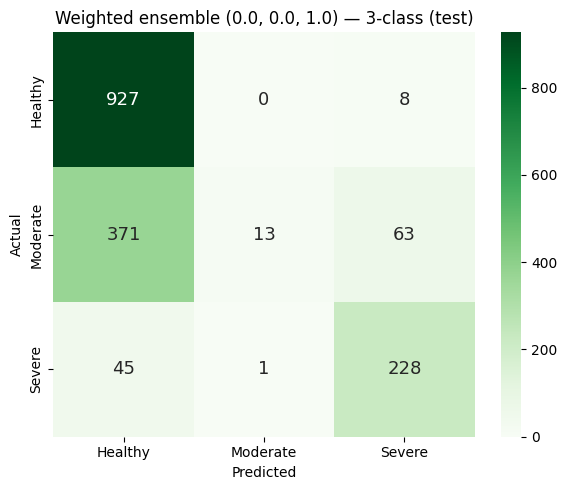

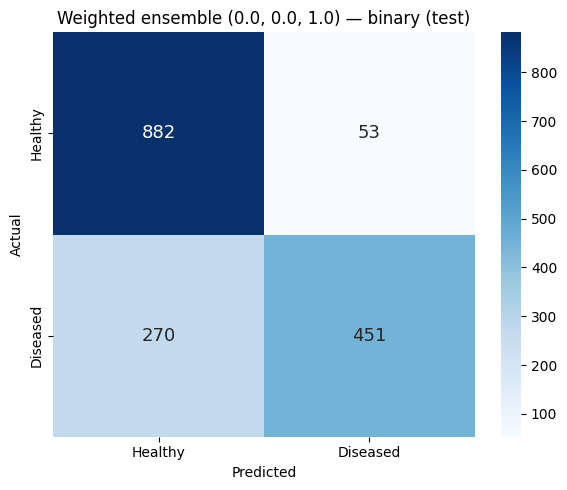

In [15]:
val_dir = os.path.join(GRADED_DIR, 'val')
print("TTA on validation set (3 models)...")
eff_pv,    y_val = predict_with_tta(model_eff,    val_dir, n_aug=5)
dense_pv,  _     = predict_with_tta(model_dense,  val_dir, n_aug=5)
resnet_pv, _     = predict_with_tta(model_resnet, val_dir, n_aug=5)

from itertools import product
t_true_val = y5_to_ternary(y_val)
grid = np.arange(0.0, 1.0 + 1e-9, 0.05)
best = (None, -1.0)
for w1, w2 in product(grid, grid):
    w3 = 1.0 - w1 - w2
    if w3 < -1e-9:
        continue
    w3 = max(0.0, w3)
    p5 = w1 * eff_pv + w2 * dense_pv + w3 * resnet_pv
    t_hat = np.argmax(probs5_to_ternary(p5), axis=1)
    f1m = f1_score(t_true_val, t_hat, average='macro')
    if f1m > best[1]:
        best = ((round(w1, 2), round(w2, 2), round(w3, 2)), f1m)

ENS_W = best[0]
print(f"Best val weights (by 3-class macro-F1): {ENS_W}  val_macroF1={best[1]:.4f}")

w1, w2, w3 = ENS_W
weighted_test = w1 * eff_p + w2 * dense_p + w3 * resnet_p
report_all_views(weighted_test, y_test, f"WEIGHTED ENSEMBLE {ENS_W} (test set)")
plot_cm(y5_to_ternary(y_test), np.argmax(probs5_to_ternary(weighted_test), axis=1),
        TERNARY_NAMES, f"Weighted ensemble {ENS_W} — 3-class (test)", 'Greens')
plot_cm(y5_to_binary(y_test), np.argmax(probs5_to_binary(weighted_test), axis=1),
        BINARY_NAMES, f"Weighted ensemble {ENS_W} — binary (test)", 'Blues')

## Cross-domain evaluation (2020 MedicalExpert-I) — the deployment number

This is the metric that predicts how the bot behaves on a stranger's X-ray.
Expect it to be lower than the test number; trust it more.

TTA on cross-domain set (3 models)...
Found 1650 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
Found 1650 images belonging to 5 classes.
CROSS-DOMAIN (2020 MedicalExpert-I)
[5-grade]  acc = 75.82%
[3-class]  acc = 85.82%  macro-F1 = 0.6745
              precision    recall  f1-score   support

     Healthy     0.8594    0.9869    0.9187     

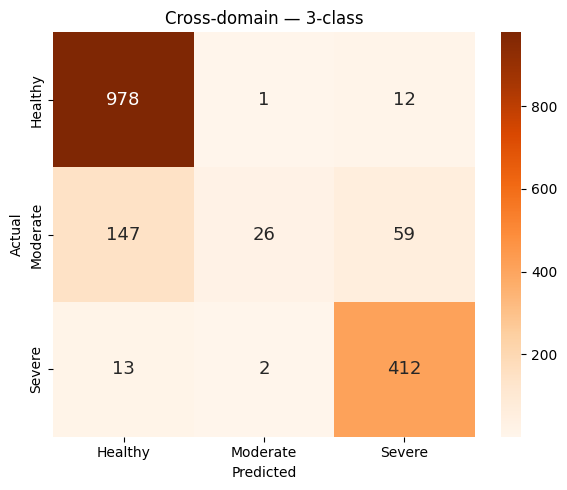

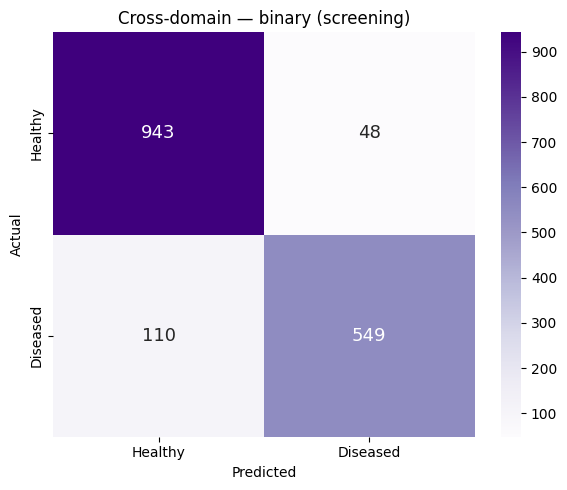

In [16]:
print("TTA on cross-domain set (3 models)...")
eff_pe,    y_extra = predict_with_tta(model_eff,    GRADED_EXTRA, n_aug=5)
dense_pe,  _       = predict_with_tta(model_dense,  GRADED_EXTRA, n_aug=5)
resnet_pe, _       = predict_with_tta(model_resnet, GRADED_EXTRA, n_aug=5)
cross_p = w1 * eff_pe + w2 * dense_pe + w3 * resnet_pe

report_all_views(cross_p, y_extra, "CROSS-DOMAIN (2020 MedicalExpert-I)")
plot_cm(y5_to_ternary(y_extra), np.argmax(probs5_to_ternary(cross_p), axis=1),
        TERNARY_NAMES, "Cross-domain — 3-class", 'Oranges')
plot_cm(y5_to_binary(y_extra), np.argmax(probs5_to_binary(cross_p), axis=1),
        BINARY_NAMES, "Cross-domain — binary (screening)", 'Purples')

## Grad-CAM sanity check (is the model looking at the joint?)
If heatmaps land outside the joint space, the model is using artefacts, not OA.

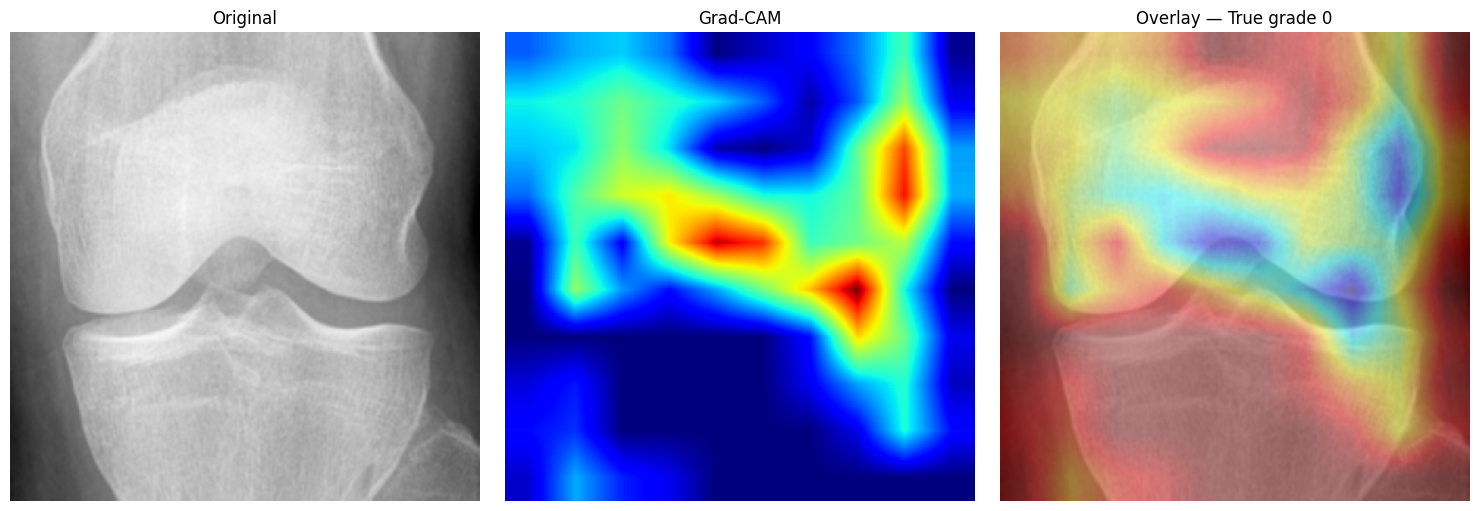

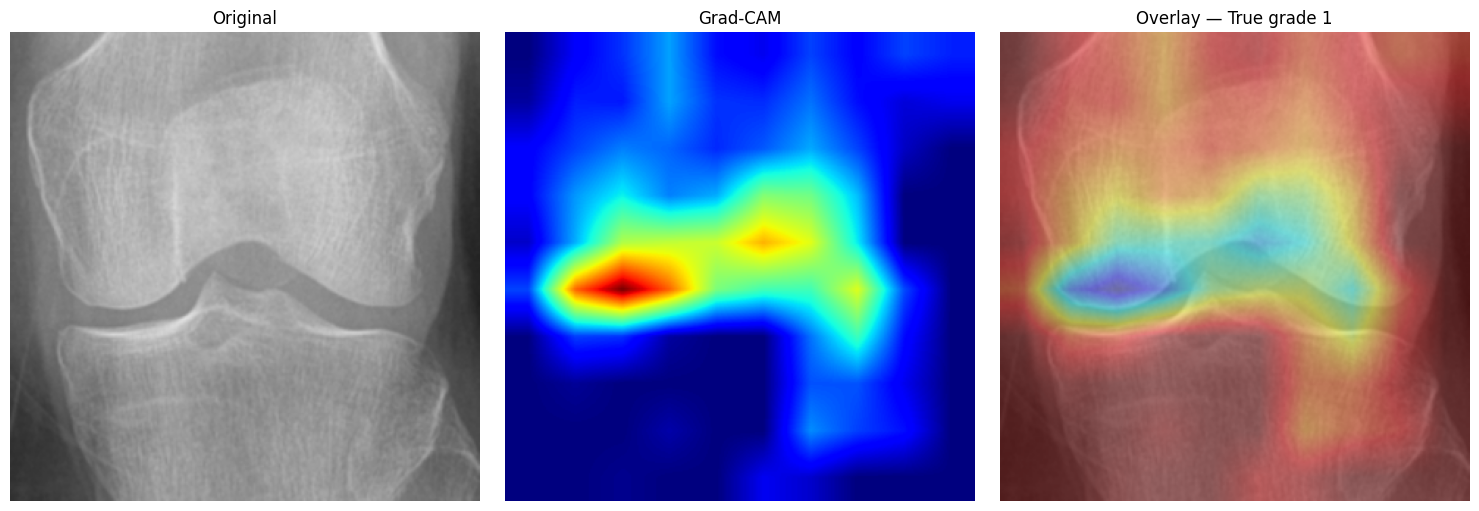

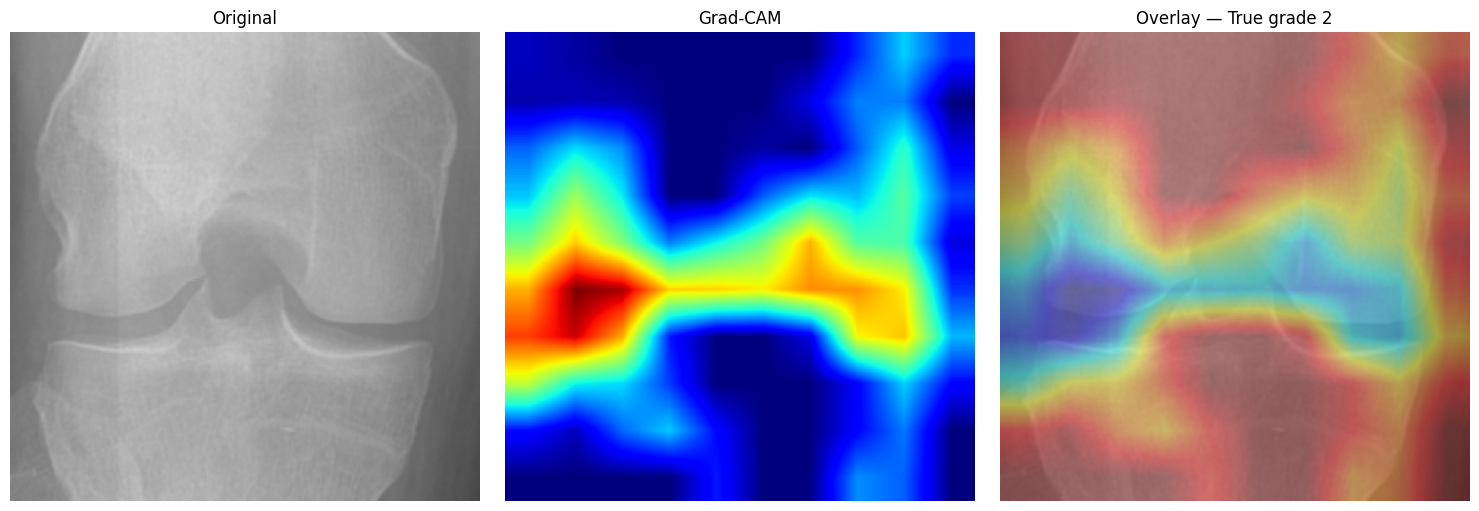

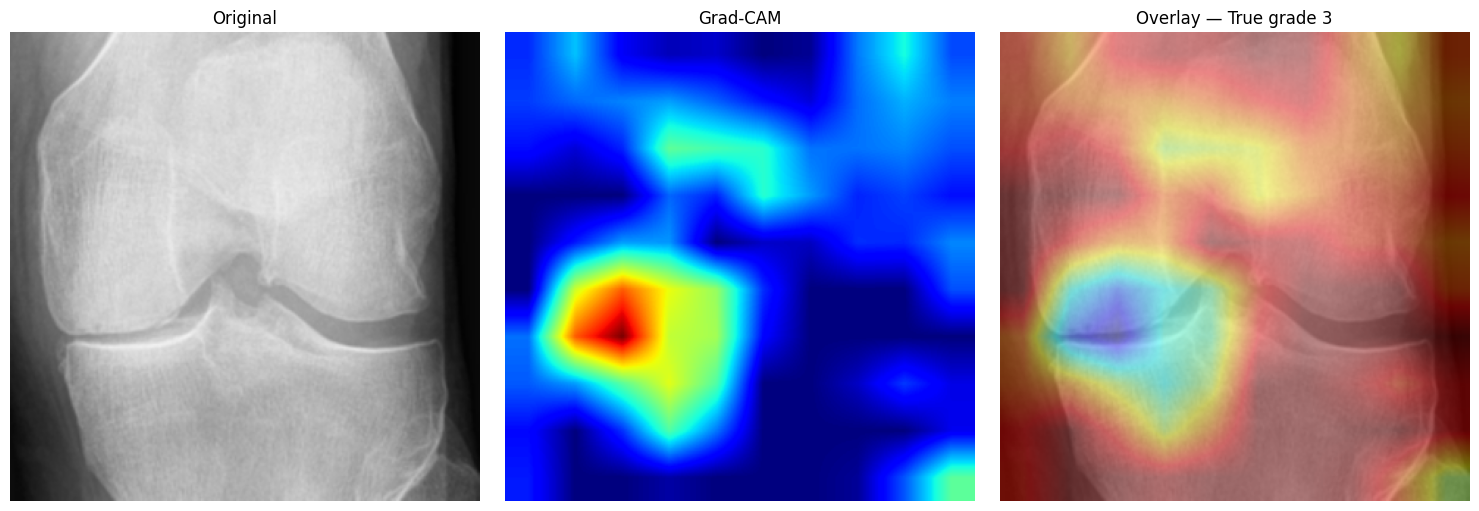

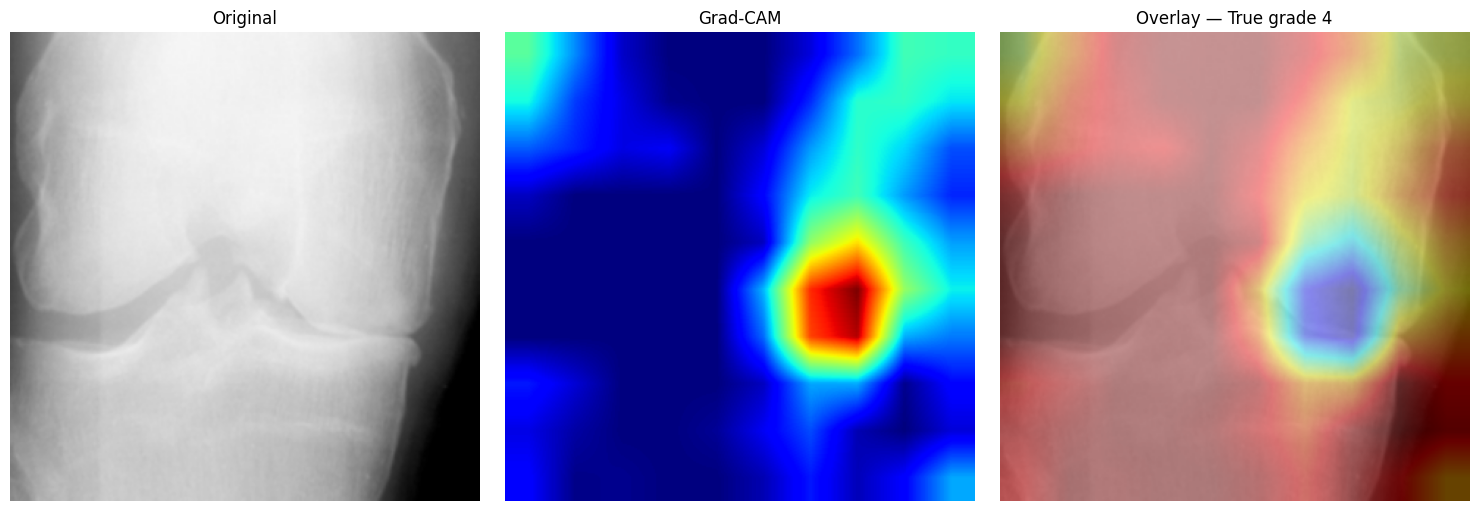

In [17]:
def get_last_conv_layer(model_name):
    return {'efficientnet': 'top_conv', 'densenet': 'relu',
            'resnet': 'post_relu'}[model_name]

def make_gradcam(img_array, model, last_conv_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        class_channel = preds[:, tf.argmax(preds[0])]
    grads = tape.gradient(class_channel, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = tf.reduce_sum(tf.multiply(conv_out, pooled), axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy().astype(np.float32)

def show_gradcam(img_path, model, model_name, title=""):
    img_pil = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_batch = np.expand_dims(clahe_preprocess(np.array(img_pil)), 0)
    heatmap = np.squeeze(make_gradcam(img_batch, model, get_last_conv_layer(model_name)))
    heatmap_r = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    heatmap_c = cv2.applyColorMap(np.uint8(255 * heatmap_r), cv2.COLORMAP_JET)
    orig = np.array(img_pil)
    overlay = cv2.addWeighted(orig, 0.6, heatmap_c, 0.4, 0)
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(orig); ax[0].set_title('Original'); ax[0].axis('off')
    ax[1].imshow(heatmap_r, cmap='jet'); ax[1].set_title('Grad-CAM'); ax[1].axis('off')
    ax[2].imshow(overlay); ax[2].set_title(f'Overlay — {title}'); ax[2].axis('off')
    plt.tight_layout(); plt.show()

for g in GRADE_NAMES:
    folder = os.path.join(GRADED_DIR, 'test', g)
    if os.path.isdir(folder) and os.listdir(folder):
        show_gradcam(os.path.join(folder, os.listdir(folder)[0]),
                     model_eff, 'efficientnet', title=f"True grade {g}")

## Save everything + config

In [18]:
model_eff.save_weights('final_g5_efficientnet.h5')
model_dense.save_weights('final_g5_densenet.h5')
model_resnet.save_weights('final_g5_resnet.h5')

config = {
    'task': '5-grade KL training, merged to 3-class and binary at inference',
    'img_size': IMG_SIZE, 'num_classes': NUM_CLASSES,
    'grade_names': GRADE_NAMES, 'ternary_names': TERNARY_NAMES,
    'binary_names': BINARY_NAMES,
    'grade_to_ternary': {str(k): v for k, v in GRADE_TO_TERNARY.items()},
    'grade_to_binary':  {str(k): v for k, v in GRADE_TO_BINARY.items()},
    'class_weights_5grade': CLASS_WEIGHTS_LIST,
    'ensemble_weights': list(ENS_W),
    'weights_files': ['final_g5_efficientnet.h5', 'final_g5_densenet.h5',
                      'final_g5_resnet.h5'],
}
with open('g5_model_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("Saved weights + g5_model_config.json")

def load_all_models():
    m1, b1 = build_model('efficientnet'); b1.trainable = True
    for l in b1.layers[:-60]: l.trainable = False
    m1.load_weights('final_g5_efficientnet.h5')
    m2, b2 = build_model('densenet'); b2.trainable = True
    for l in b2.layers[:-60]: l.trainable = False
    m2.load_weights('final_g5_densenet.h5')
    m3, b3 = build_model('resnet'); b3.trainable = True
    for l in b3.layers[:-60]: l.trainable = False
    m3.load_weights('final_g5_resnet.h5')
    print("All 3 models loaded.")
    return m1, m2, m3
print("Reload helper ready: model_eff, model_dense, model_resnet = load_all_models()")

Saved weights + g5_model_config.json
Reload helper ready: model_eff, model_dense, model_resnet = load_all_models()


## Deployment inference — what the bot calls

Returns a **binary screening verdict** (the reliable signal) plus a tentative
severity, with a confidence gate that routes uncertain cases to "see a
clinician", and a mandatory disclaimer. Do not strip the disclaimer.

In [19]:
# ===== DEPLOYMENT — single image through the TRAINED CASCADE =====
DISCLAIMER = ("This is an automated screening aid, NOT a medical diagnosis. "
              "X-ray screening can be wrong, especially for early/borderline cases. "
              "Please consult a qualified clinician.")

def predict_xray_cascade(img_path):
    img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    batch = np.expand_dims(clahe_preprocess(np.array(img)), 0)
    w1, w2, w3 = ENS_W
    p5 = (w1*model_eff.predict(batch, verbose=0)[0]
          + w2*model_dense.predict(batch, verbose=0)[0]
          + w3*model_resnet.predict(batch, verbose=0)[0])
    p_diseased = float(p5[2] + p5[3] + p5[4])
    if p_diseased < CASCADE_S1_THR:
        return {'screening': 'Healthy', 'diseased_prob': round(p_diseased, 3),
                'severity': None,
                'message': f"Screening: Healthy ({(1-p_diseased)*100:.0f}%).",
                'disclaimer': DISCLAIMER}
    ps = (spec_eff.predict(batch, verbose=0)[0]
          + spec_dense.predict(batch, verbose=0)[0]
          + spec_resnet.predict(batch, verbose=0)[0]) / 3.0
    p_sev = float(ps[1])
    severity = 'Severe' if p_sev >= CASCADE_S2_THR else 'Moderate'
    return {'screening': 'Diseased', 'diseased_prob': round(p_diseased, 3),
            'severity': severity, 'severity_severe_prob': round(p_sev, 3),
            'message': f"Screening: Diseased ({p_diseased*100:.0f}%). "
                       f"Tentative severity: {severity}.",
            'disclaimer': DISCLAIMER}

for g in GRADE_NAMES:
    folder = os.path.join(GRADED_DIR, 'test', g)
    if os.path.isdir(folder) and os.listdir(folder):
        out = predict_xray_cascade(os.path.join(folder, os.listdir(folder)[0]))
        print(f"True grade {g} -> {out['message']}")



True grade 0 -> Screening: Healthy (confidence 84%).
True grade 1 -> Screening: Healthy (confidence 82%).
True grade 2 -> UNCERTAIN — please see a clinician for assessment.
True grade 3 -> Screening: Diseased (confidence 94%). Tentative severity: Severe (79%).
True grade 4 -> Screening: Diseased (confidence 93%). Tentative severity: Severe (85%).


In [20]:
# ===== PATCH: optimize ensemble + threshold for the BINARY screening product =====
from itertools import product

# 1) Re-tune weights on VALIDATION for binary macro-F1 (not 3-class)
b_true_val = y5_to_binary(y_val)
grid = np.arange(0.0, 1.0 + 1e-9, 0.05)
best_w, best_f1 = None, -1.0
for w1, w2 in product(grid, grid):
    w3 = 1.0 - w1 - w2
    if w3 < -1e-9:
        continue
    w3 = max(0.0, w3)
    pb = probs5_to_binary(w1*eff_pv + w2*dense_pv + w3*resnet_pv)
    f1 = f1_score(b_true_val, np.argmax(pb, axis=1), average='macro')
    if f1 > best_f1:
        best_f1, best_w = f1, (round(w1, 2), round(w2, 2), round(w3, 2))
BIN_W = best_w
print(f"Binary-optimized weights (val): {BIN_W}  val binary macro-F1={best_f1:.4f}")

# 2) Pick a threshold on VALIDATION favouring sensitivity (catch disease)
w1, w2, w3 = BIN_W
val_pdis = probs5_to_binary(w1*eff_pv + w2*dense_pv + w3*resnet_pv)[:, 1]
target_recall = 0.90
best_thr, best_acc = 0.5, -1.0
for thr in np.arange(0.20, 0.81, 0.02):
    pred = (val_pdis >= thr).astype(int)
    rec = ((pred == 1) & (b_true_val == 1)).sum() / max((b_true_val == 1).sum(), 1)
    acc = accuracy_score(b_true_val, pred)
    if rec >= target_recall and acc > best_acc:
        best_acc, best_thr = acc, thr
print(f"Chosen threshold (val, Diseased recall>={target_recall}): {best_thr:.2f}")

# 3) Apply to CROSS-DOMAIN (the deployment number)
b_true_x = y5_to_binary(y_extra)
x_pdis = probs5_to_binary(w1*eff_pe + w2*dense_pe + w3*resnet_pe)[:, 1]
x_pred = (x_pdis >= best_thr).astype(int)
print("=== CROSS-DOMAIN BINARY (tuned) ===")
print(f"acc={accuracy_score(b_true_x, x_pred)*100:.2f}%  "
      f"macro-F1={f1_score(b_true_x, x_pred, average='macro'):.4f}")
print(classification_report(b_true_x, x_pred, target_names=BINARY_NAMES, digits=4))
print(confusion_matrix(b_true_x, x_pred))

BINARY_WEIGHTS = BIN_W
BINARY_THRESHOLD = float(best_thr)
print(f"Stored BINARY_WEIGHTS={BINARY_WEIGHTS}, BINARY_THRESHOLD={BINARY_THRESHOLD}")

Binary-optimized weights (val): (0.15, 0.0, 0.85)  val binary macro-F1=0.7726
Chosen threshold (val, Diseased recall>=0.9): 0.32
=== CROSS-DOMAIN BINARY (tuned) ===
acc=86.73%  macro-F1=0.8660
              precision    recall  f1-score   support

     Healthy     0.9696    0.8042    0.8792       991
    Diseased     0.7657    0.9621    0.8527       659

    accuracy                         0.8673      1650
   macro avg     0.8676    0.8832    0.8660      1650
weighted avg     0.8882    0.8673    0.8686      1650

[[797 194]
 [ 25 634]]
Stored BINARY_WEIGHTS=(0.15, 0.0, 0.85), BINARY_THRESHOLD=0.31999999999999995


In [21]:
# ===== CASCADE: Stage1 Healthy/Diseased -> Stage2 Moderate/Severe =====
# Free — re-decomposes the existing 5-grade ensemble probs. No training.
w1, w2, w3 = ENS_W
P5_val  = w1*eff_pv + w2*dense_pv + w3*resnet_pv
P5_test = w1*eff_p  + w2*dense_p  + w3*resnet_p
P5_xdom = w1*eff_pe + w2*dense_pe + w3*resnet_pe

def cascade_to_ternary(p5, s1_thr=0.5):
    pM = p5[:, 2]; pS = p5[:, 3] + p5[:, 4]
    pD = pM + pS                       # P(Diseased)
    out = np.zeros(len(p5), dtype=int) # 0=Healthy default
    diseased = pD >= s1_thr
    out[diseased & (pS >= pM)] = 2     # Severe
    out[diseased & (pS <  pM)] = 1     # Moderate
    return out

# Tune Stage-1 threshold on VALIDATION (3-class macro-F1), apply once to test/cross-domain
tv = y5_to_ternary(y_val)
best_thr, best = 0.5, -1.0
for thr in np.arange(0.30, 0.71, 0.02):
    f = f1_score(tv, cascade_to_ternary(P5_val, thr), average='macro')
    if f > best: best, best_thr = f, thr
print(f"Cascade Stage-1 threshold (val): {best_thr:.2f}  val macro-F1={best:.4f}")

for name, P5, y in [("TEST", P5_test, y_test), ("CROSS-DOMAIN", P5_xdom, y_extra)]:
    tt, yh = y5_to_ternary(y), cascade_to_ternary(P5, best_thr)
    print("=" * 60); print(f"CASCADE — {name}")
    print(f"3-class acc={accuracy_score(tt, yh)*100:.2f}%  "
          f"macro-F1={f1_score(tt, yh, average='macro'):.4f}")
    print(classification_report(tt, yh, target_names=TERNARY_NAMES, digits=4))
    print(confusion_matrix(tt, yh))

Cascade Stage-1 threshold (val): 0.38  val macro-F1=0.6215
CASCADE — TEST
3-class acc=69.81%  macro-F1=0.6495
              precision    recall  f1-score   support

     Healthy     0.8430    0.7754    0.8078       935
    Moderate     0.5278    0.3826    0.4436       447
      Severe     0.5508    0.9489    0.6971       274

    accuracy                         0.6981      1656
   macro avg     0.6405    0.7023    0.6495      1656
weighted avg     0.7096    0.6981    0.6912      1656

[[725 143  67]
 [131 171 145]
 [  4  10 260]]
CASCADE — CROSS-DOMAIN
3-class acc=83.94%  macro-F1=0.7549
              precision    recall  f1-score   support

     Healthy     0.9512    0.8658    0.9065       991
    Moderate     0.5668    0.4569    0.5060       232
      Severe     0.7504    0.9859    0.8522       427

    accuracy                         0.8394      1650
   macro avg     0.7562    0.7695    0.7549      1650
weighted avg     0.8452    0.8394    0.8361      1650

[[858  75  58]
 [ 44 10

In [22]:
# =====================================================================
# STAGE-2 SPECIALIST (Moderate vs Severe) — trained cascade
# Stage 1 = your existing ~90% Healthy-vs-Diseased screener (5-grade ensemble).
# Stage 2 = NEW binary specialist trained ONLY on diseased knees (grade 2 vs 3+4),
#           so all its capacity goes to the Moderate/Severe split.
# =====================================================================


# %% Cell S2-1 — Build the Stage-2 dataset (Moderate vs Severe), diseased only
import os, shutil

STAGE2_DIR = r"stage2_mod_vs_sev"   # train/val/test, folders: Moderate / Severe

if os.path.exists(STAGE2_DIR):
    print(f"Cleaning {STAGE2_DIR} ...")
    shutil.rmtree(STAGE2_DIR, onerror=remove_readonly)

# grade 2 -> Moderate ; grades 3,4 -> Severe.  Source = the 5-grade dataset.
GRADE_TO_S2 = {'2': 'Moderate', '3': 'Severe', '4': 'Severe'}

print("Building Stage-2 (Moderate vs Severe) from the diseased grades...")
for split in ['train', 'val', 'test']:
    for grade, s2cls in GRADE_TO_S2.items():
        src = os.path.join(GRADED_DIR, split, grade)
        if not os.path.isdir(src):
            continue
        dst = os.path.join(STAGE2_DIR, split, s2cls)
        os.makedirs(dst, exist_ok=True)
        for f in os.listdir(src):
            shutil.copy2(os.path.join(src, f), os.path.join(dst, f"g{grade}_{f}"))

print("Stage-2 counts:")
for split in ['train', 'val', 'test']:
    sd = os.path.join(STAGE2_DIR, split)
    counts = {c: len(os.listdir(os.path.join(sd, c))) for c in sorted(os.listdir(sd))}
    print(f"  {split}: {counts}  (total {sum(counts.values())})")


Building Stage-2 (Moderate vs Severe) from the diseased grades...
Stage-2 counts:
  train: {'Moderate': 1748, 'Severe': 1357}  (total 3105)
  val: {'Moderate': 212, 'Severe': 133}  (total 345)
  test: {'Moderate': 447, 'Severe': 274}  (total 721)


In [23]:
# %% Cell S2-2 — Binary model builder + specialist trainer + n-class TTA
def build_specialist(model_name='efficientnet'):
    """2-class head on the same backbone you already use."""
    preprocess_fn = get_preprocess_fn(model_name)
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = Lambda(preprocess_fn)(inputs)
    if model_name == 'efficientnet':
        base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=x)
    elif model_name == 'densenet':
        base = DenseNet121(weights='imagenet', include_top=False, input_tensor=x)
    elif model_name == 'resnet':
        base = ResNet50V2(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False
    h = base.output
    h = GlobalAveragePooling2D()(h)
    h = BatchNormalization()(h)
    h = Dense(256, activation='relu')(h); h = Dropout(0.5)(h)
    h = Dense(128, activation='relu')(h); h = Dropout(0.3)(h)
    out = Dense(2, activation='softmax', dtype='float32')(h)
    return Model(inputs, out), base
 
 
def predict_with_tta_n(model, source_dir, n_classes, n_aug=5):
    """TTA prediction for an n-class model (your predict_with_tta, generalised)."""
    base_gen = eval_datagen.flow_from_directory(
        source_dir, target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
    n = base_gen.samples
    probs = np.zeros((n, n_classes))
    base_gen.reset()
    probs += model.predict(base_gen, verbose=0)
    tta_aug = ImageDataGenerator(
        preprocessing_function=clahe_preprocess, rotation_range=10,
        horizontal_flip=True, zoom_range=0.05,
        width_shift_range=0.05, height_shift_range=0.05)
    for i in range(n_aug):
        g = tta_aug.flow_from_directory(
            source_dir, target_size=(IMG_SIZE, IMG_SIZE),
            batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False, seed=42 + i)
        probs += model.predict(g, verbose=0)
    probs /= (n_aug + 1)
    return probs, base_gen.classes
 
 
def train_specialist(model_name, save_path, epochs_p1=12, epochs_p2=15):
    if not save_path.endswith('.h5'):
        save_path = save_path.rsplit('.', 1)[0] + '.h5'
    print(f"{'='*22} Specialist: {model_name.upper()} {'='*22}")
    tg = train_datagen.flow_from_directory(
        os.path.join(STAGE2_DIR, 'train'), target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True)
    vg = eval_datagen.flow_from_directory(
        os.path.join(STAGE2_DIR, 'val'), target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
    print("  class indices (expect {'Moderate':0,'Severe':1}):", tg.class_indices)
 
    cw = compute_class_weight('balanced', classes=np.unique(tg.classes), y=tg.classes)
    cw = [float(w) for w in cw]
    print("  class weights:", cw)
 
    tds = to_tf_dataset(MixupGenerator(tg, alpha=0.2), training=True, n_classes=2)
    vds = to_tf_dataset(vg, training=False, n_classes=2)
    steps_t, steps_v = len(tg), len(vg)
 
    model, base = build_specialist(model_name)
    # Phase 1: head only
    model.compile(optimizer=Adam(1e-3),
                  loss=WeightedFocalLoss(class_weights=cw), metrics=['accuracy'])
    model.fit(tds, steps_per_epoch=steps_t, validation_data=vds, validation_steps=steps_v,
              epochs=epochs_p1, callbacks=make_callbacks(save_path, 5), verbose=1)
    # Phase 2: fine-tune top 60
    base.trainable = True
    for l in base.layers[:-60]:
        l.trainable = False
    model.compile(optimizer=Adam(1e-5),
                  loss=WeightedFocalLoss(class_weights=cw), metrics=['accuracy'])
    model.fit(tds, steps_per_epoch=steps_t, validation_data=vds, validation_steps=steps_v,
              epochs=epochs_p2, callbacks=make_callbacks(save_path, 6), verbose=1)
    model.save_weights(save_path.replace('.h5', '_final.h5'))
    print(f"  saved best -> {save_path}")
    return model

In [24]:
# %% Cell S2-3 — Train the 3 specialists (~1–1.5 hr total; smaller data than Stage 1)
spec_eff    = train_specialist('efficientnet', 'spec_efficientnet.h5')
spec_dense  = train_specialist('densenet',     'spec_densenet.h5')
spec_resnet = train_specialist('resnet',       'spec_resnet.h5')
print("All 3 specialists trained.")

====================== Specialist: EFFICIENTNET ======================
Found 3105 images belonging to 2 classes.
Found 345 images belonging to 2 classes.
  class indices (expect {'Moderate':0,'Severe':1}): {'Moderate': 0, 'Severe': 1}
  class weights: [0.8881578947368421, 1.1440677966101696]
Epoch 1/12
98/98 [==============================] - ETA: 0s - loss: 0.1096 - accuracy: 0.5787
Epoch 1: val_accuracy improved from -inf to 0.74783, saving model to spec_efficientnet.h5
98/98 [==============================] - 198s 2s/step - loss: 0.1096 - accuracy: 0.5787 - val_loss: 0.0375 - val_accuracy: 0.7478 - lr: 0.0010
Epoch 2/12
98/98 [==============================] - ETA: 0s - loss: 0.0603 - accuracy: 0.6044
Epoch 2: val_accuracy did not improve from 0.74783
98/98 [==============================] - 169s 2s/step - loss: 0.0603 - accuracy: 0.6044 - val_loss: 0.0391 - val_accuracy: 0.7072 - lr: 0.0010
Epoch 3/12
98/98 [==============================] - ETA: 0s - loss: 0.0472 - accuracy: 0.604

In [25]:
# %% Cell S2-4 — Specialist TTA on val/test/cross-domain + standalone accuracy
# NOTE: we run on the FULL 5-grade directories (shuffle=False), so the row order
# matches eff_p / eff_pv / eff_pe exactly. P(Severe) is column index 1.
val_dir  = os.path.join(GRADED_DIR, 'val')
test_dir = os.path.join(GRADED_DIR, 'test')
 
def spec_ensemble_probs(source_dir):
    pe, _ = predict_with_tta_n(spec_eff,    source_dir, 2, n_aug=5)
    pd, _ = predict_with_tta_n(spec_dense,  source_dir, 2, n_aug=5)
    pr, y = predict_with_tta_n(spec_resnet, source_dir, 2, n_aug=5)
    return (pe + pd + pr) / 3.0, y
 
print("Specialist TTA on val / test / cross-domain ...")
spec_val,   yv_chk = spec_ensemble_probs(val_dir)
spec_test,  yt_chk = spec_ensemble_probs(test_dir)
spec_cross, ye_chk = spec_ensemble_probs(GRADED_EXTRA)
assert np.array_equal(yt_chk, y_test) and np.array_equal(ye_chk, y_extra) \
       and np.array_equal(yv_chk, y_val), "Row order mismatch — re-run TTA cells."
 
# Standalone specialist accuracy on the DISEASED subset only (grade2=Mod, 3/4=Sev)
for name, sp, y in [("TEST", spec_test, y_test), ("CROSS-DOMAIN", spec_cross, y_extra)]:
    dis = y >= 2
    true_ms = (y[dis] >= 3).astype(int)        # 0=Moderate, 1=Severe
    pred_ms = np.argmax(sp[dis], axis=1)
    acc = accuracy_score(true_ms, pred_ms) * 100
    rec_mod = ((pred_ms == 0) & (true_ms == 0)).sum() / max((true_ms == 0).sum(), 1)
    print(f"  Specialist on {name} diseased: acc={acc:.2f}%  Moderate-recall={rec_mod*100:.1f}%")

Specialist TTA on val / test / cross-domain ...
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 826 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Found 1656 images belonging to 5 classes.
Foun

Tuned on val -> Stage1 thr=0.38, Stage2 thr=0.5  (val macro-F1=0.6541)
TRAINED CASCADE — TEST
3-class acc=69.57%  macro-F1=0.6569
              precision    recall  f1-score   support

     Healthy     0.8430    0.7754    0.8078       935
    Moderate     0.4757    0.5705    0.5188       447
      Severe     0.6615    0.6277    0.6442       274

    accuracy                         0.6957      1656
   macro avg     0.6601    0.6579    0.6569      1656
weighted avg     0.7139    0.6957    0.7027      1656



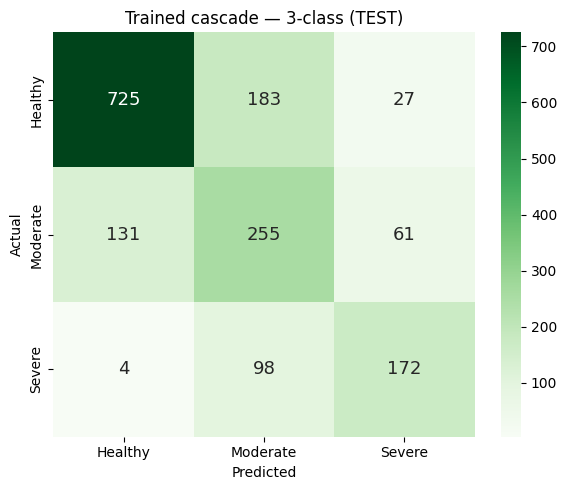

TRAINED CASCADE — CROSS-DOMAIN
3-class acc=83.21%  macro-F1=0.7568
              precision    recall  f1-score   support

     Healthy     0.9512    0.8658    0.9065       991
    Moderate     0.6114    0.5086    0.5553       232
      Severe     0.7153    0.9297    0.8086       427

    accuracy                         0.8321      1650
   macro avg     0.7593    0.7681    0.7568      1650
weighted avg     0.8424    0.8321    0.8318      1650



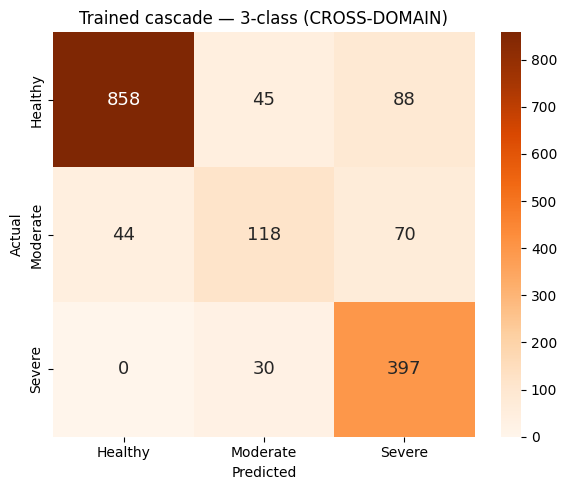

Stored: CASCADE_S1_THR=0.38, CASCADE_S2_THR=0.5


In [28]:
# %% Cell S2-5 — Wire the trained cascade, tune thresholds on VAL, report
def cascade_predict(P5, p_severe, s1_thr, s2_thr):
    """Stage1: Diseased if (P2+P3+P4)>=s1_thr.  Stage2: Severe if specialist P(Sev)>=s2_thr."""
    pD = P5[:, 2] + P5[:, 3] + P5[:, 4]
    out = np.zeros(len(P5), dtype=int)         # 0 = Healthy
    diseased = pD >= s1_thr
    out[diseased & (p_severe >= s2_thr)] = 2   # Severe
    out[diseased & (p_severe <  s2_thr)] = 1   # Moderate
    return out
 
w1, w2, w3 = ENS_W
P5_val   = w1*eff_pv + w2*dense_pv + w3*resnet_pv
P5_test  = w1*eff_p  + w2*dense_p  + w3*resnet_p
P5_cross = w1*eff_pe + w2*dense_pe + w3*resnet_pe
 
# Joint threshold tuning on VALIDATION (3-class macro-F1) — no test peeking
tv = y5_to_ternary(y_val)
best = (0.5, 0.5, -1.0)
for s1 in np.arange(0.30, 0.71, 0.02):
    for s2 in np.arange(0.30, 0.71, 0.02):
        f = f1_score(tv, cascade_predict(P5_val, spec_val[:, 1], s1, s2), average='macro')
        if f > best[2]:
            best = (round(float(s1), 2), round(float(s2), 2), f)
S1_THR, S2_THR = best[0], best[1]
print(f"Tuned on val -> Stage1 thr={S1_THR}, Stage2 thr={S2_THR}  (val macro-F1={best[2]:.4f})")
 
for name, P5, psev, y, cmap in [
        ("TEST",         P5_test,  spec_test[:, 1],  y_test,  'Greens'),
        ("CROSS-DOMAIN", P5_cross, spec_cross[:, 1], y_extra, 'Oranges')]:
    tt = y5_to_ternary(y)
    yh = cascade_predict(P5, psev, S1_THR, S2_THR)
    print("=" * 64); print(f"TRAINED CASCADE — {name}")
    print(f"3-class acc={accuracy_score(tt, yh)*100:.2f}%  "
          f"macro-F1={f1_score(tt, yh, average='macro'):.4f}")
    print(classification_report(tt, yh, target_names=TERNARY_NAMES, digits=4))
    cm = confusion_matrix(tt, yh)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=TERNARY_NAMES, yticklabels=TERNARY_NAMES, annot_kws={'size': 13})
    plt.title(f"Trained cascade — 3-class ({name})")
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.tight_layout(); plt.show()
 
# Store for deployment
CASCADE_S1_THR, CASCADE_S2_THR = S1_THR, S2_THR
print(f"Stored: CASCADE_S1_THR={CASCADE_S1_THR}, CASCADE_S2_THR={CASCADE_S2_THR}")

In [29]:
# %% Cell S2-6 — Stage-1 threshold sweep (recover Moderate leaks). No retrain.
# Lower Stage1 thr => fewer Moderate->Healthy leaks, but more Healthy false alarms.
# We keep Stage2 thr fixed at the tuned value and sweep Stage1 only.

s2 = CASCADE_S2_THR   # keep the specialist split as-is

def cascade_metrics(P5, psev, y, s1):
    tt = y5_to_ternary(y)
    yh = cascade_predict(P5, psev, s1, s2)
    mod_leak = ((yh == 0) & (tt == 1)).sum()                 # Moderate called Healthy
    health_fa = ((yh != 0) & (tt == 0)).sum()                # Healthy called diseased
    return (accuracy_score(tt, yh),
            f1_score(tt, yh, average='macro'),
            ((yh == 1) & (tt == 1)).sum() / max((tt == 1).sum(), 1),  # Moderate recall
            mod_leak, health_fa)

tv = y5_to_ternary(y_val)
print(f"{'s1_thr':>7} | {'VAL acc':>8} {'VAL F1':>8} {'VAL modR':>9} {'modLeak':>8} {'healthFA':>9}")
rows = []
for s1 in np.arange(0.10, 0.51, 0.02):
    acc, f1m, modr, leak, fa = cascade_metrics(P5_val, spec_val[:, 1], y_val, s1)
    rows.append((round(float(s1), 2), f1m, acc))
    print(f"{s1:7.2f} | {acc*100:7.2f}% {f1m:8.4f} {modr*100:8.1f}% {leak:8d} {fa:9d}")

# Pick the Stage-1 threshold that maximises VAL macro-F1 (balances recall vs false alarms)
best_s1 = max(rows, key=lambda r: r[1])[0]
print(f"\nValidation-optimal Stage1 threshold: {best_s1}  (was {CASCADE_S1_THR})")

# Report old vs new on CROSS-DOMAIN
for tag, s1 in [("OLD", CASCADE_S1_THR), ("NEW", best_s1)]:
    acc, f1m, modr, leak, fa = cascade_metrics(P5_cross, spec_cross[:, 1], y_extra, s1)
    print(f"\n[{tag} s1={s1}] CROSS-DOMAIN  acc={acc*100:.2f}%  macroF1={f1m:.4f}  "
          f"Moderate-recall={modr*100:.1f}%  Mod->Healthy leaks={leak}  Healthy false-alarms={fa}")

tt = y5_to_ternary(y_extra)
yh = cascade_predict(P5_cross, spec_cross[:, 1], best_s1, s2)
print("\n" + classification_report(tt, yh, target_names=TERNARY_NAMES, digits=4))
print(confusion_matrix(tt, yh))

# CASCADE_S1_THR = float(best_s1)   # update stored threshold for deployment
# print(f"\nUpdated CASCADE_S1_THR={CASCADE_S1_THR}")

 s1_thr |  VAL acc   VAL F1  VAL modR  modLeak  healthFA
   0.10 |   32.93%   0.3529     84.9%        0       480
   0.12 |   33.66%   0.3620     84.9%        0       474
   0.14 |   34.75%   0.3753     84.9%        0       465
   0.16 |   36.80%   0.3993     84.9%        0       448
   0.18 |   39.71%   0.4317     84.4%        1       423
   0.20 |   42.37%   0.4604     82.5%        5       397
   0.22 |   44.92%   0.4857     80.2%       10       371
   0.24 |   49.39%   0.5247     79.7%       11       333
   0.26 |   53.03%   0.5542     79.7%       11       303
   0.28 |   56.17%   0.5779     76.4%       18       270
   0.30 |   59.20%   0.5988     73.1%       25       238
   0.32 |   63.32%   0.6263     69.8%       33       197
   0.34 |   65.25%   0.6339     62.7%       48       166
   0.36 |   67.07%   0.6438     59.4%       55       144
   0.38 |   68.89%   0.6541     56.6%       61       123
   0.40 |   70.46%   0.6537     49.1%       77        93
   0.42 |   70.70%   0.6461    

In [30]:
CASCADE_S1_THR = 0.38   # balanced/reported. Use 0.30 instead for a sensitivity-favoured screener.
CASCADE_S2_THR = CASCADE_S2_THR
print(f"Deployment thresholds: Stage1={CASCADE_S1_THR}, Stage2={CASCADE_S2_THR}")

Deployment thresholds: Stage1=0.38, Stage2=0.5


## Notes for the WhatsApp / Telegram bot

- Call `predict_xray_for_bot(path)` and send back `message` + `disclaimer`.
  Always send the disclaimer; never send a bare grade.
- The **binary screening** verdict is the trustworthy output. Treat the 3-class
  severity as a hint, not a diagnosis — Moderate (KL2) is the weakest class.
- Reject non-X-ray images before inference (a simple check or a tiny
  "is this a knee X-ray" gate) — strangers will send selfies.
- Tune `binary_conf_gate` using the **cross-domain** confusion matrix above, not
  the test one.
- Re-read the cross-domain numbers before publishing: that is the accuracy your
  users will actually experience.